In [2]:
# import clr  # From pythonnet
import os
import random
import numpy as np
import pandas as pd
from sklearn.cluster import MeanShift
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import ParameterSampler, ParameterGrid
# from dwsim_pilot_parametric_study import parametric_study

In [3]:
# Paths
dwsim_path = r"C:\Users\rafae\AppData\Local\DWSIM\\"
sim_path = r"C:\Users\rafae\Documents\Rafael Duarte\SAF_kinetics_paper_code_with_WGS\SAF_kinetics_paper_code_with_WGS\dwsim_pilot_model_parametric.dwxmz"

In [4]:
v0 = 730 # L / min
v0 = v0 / ( 1000 * 60 ) # m3 / s

F0 = v0 * 1e5 / ( 8.314 * 273 ) # mol / s

H2_CO_in = 2
F_H2_in = F0 * (H2_CO_in / ( 1 + H2_CO_in )) # mol / s

param_grid = {'T_K'        : np.arange(210 + 273.15, 300 + 273.15, 10), 
              'P_Pa'       : np.arange(5e5, 35e5, 1e5),
              'F_H2_in'    : [F_H2_in],
              'F_CO_in'    : [0],
              'phi_220C'   : [2, 4, 10],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))
parametric_data.F_CO_in = F0 - parametric_data.F_H2_in
parametric_data['phi'] = parametric_data['phi_220C'] * ( 
        ( 493 / parametric_data['T_K'] ) * np.exp( - ( 147203.9 / 8.314 ) * ( 1/parametric_data['T_K'] - 1/493 ) ) 
    ) ** (1/2)
parametric_data['eff'] = np.tanh(parametric_data['phi'])/parametric_data['phi']

parametric_data = parametric_study(parametric_data, num_workers:=16, dwsim_path, sim_path)
parametric_data.to_pickle('parametric_data_dwsim_pilot.pkl')

In [5]:
parametric_data = pd.read_pickle('parametric_data_dwsim_pilot.pkl')

In [18]:
parametric_data['C9_C15_sel'] = parametric_data['C9-C15 mass flow (kg/d)']/(
    parametric_data[['C1-C8 mass flow (kg/d)', 'C16p mass flow (kg/d)']].sum(axis = 'columns')
)
parametric_data['C1_C8_sel'] = parametric_data['C1-C8 mass flow (kg/d)']/(
    parametric_data[['C9-C15 mass flow (kg/d)', 'C16p mass flow (kg/d)']].sum(axis = 'columns')
)
parametric_data['C16p_sel'] = parametric_data['C16p mass flow (kg/d)']/(
    parametric_data[['C9-C15 mass flow (kg/d)', 'C1-C8 mass flow (kg/d)']].sum(axis = 'columns')
)
parametric_data['H2_CO'] = parametric_data.F_H2_in / parametric_data.F_CO_in
parametric_data['T (ºC)'] = parametric_data.T_K - 273.15
parametric_data['P (bar)'] = parametric_data.P_Pa / 1e5
parametric_data[r'$\mathrm{X_{CO}}$'] = (
    (parametric_data.F_CO_in - parametric_data['F_Carbon monoxide_out_dwsim']) / parametric_data.F_CO_in
)
parametric_data[r'$\mathrm{X_{H_2}}$'] = (
    (parametric_data.F_H2_in - parametric_data['F_Hydrogen_out_dwsim']) / parametric_data.F_H2_in
)
parametric_data[r'$\mathrm{v_{CO,in}}$ (L/min)'] =  1000 * 60 * parametric_data.F_CO_in * 8.314 * 273 / 1e5
parametric_data[r'$\mathrm{v_{H_2,in}}$ (L/min)'] = 1000 * 60 * parametric_data.F_H2_in * 8.314 * 273 / 1e5

In [19]:
parametric_data[[r'$\mathrm{\dot{m}_{C1-C8}}$ (kg/d)', 
                 r'$\mathrm{\dot{m}_{C9-C15}}$ (kg/d)', 
                 r'$\mathrm{\dot{m}_{C16+}}$ (kg/d)', 
                 r'$\mathrm{\dot{m}_{H_2O}}$ (kg/d)']] = parametric_data[['C1-C8 mass flow (kg/d)', 
                                                                        'C9-C15 mass flow (kg/d)', 
                                                                        'C16p mass flow (kg/d)', 
                                                                        'water mass flow (kg/d)']]

In [20]:
parametric_data.to_excel('parametric_data_dwsim_pilot.ods')

In [21]:
parametric_data.loc[parametric_data[r'$\mathrm{\dot{m}_{C9-C15}}$ (kg/d)'] == parametric_data[r'$\mathrm{\dot{m}_{C9-C15}}$ (kg/d)'].max()]

,F_CO_in,F_H2_in,P_Pa,T_K,phi_220C,phi,eff,Reactor Energy Flow (kW),CO in mass flow (kg/d),H2 in mass flow (kg/d),...,$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,"$\mathrm{v_{CO,in}}$ (L/min)","$\mathrm{v_{H_2,in}}$ (L/min)",$\mathrm{\dot{m}_{C1-C8}}$ (kg/d),$\mathrm{\dot{m}_{C9-C15}}$ (kg/d),$\mathrm{\dot{m}_{C16+}}$ (kg/d),$\mathrm{\dot{m}_{H_2O}}$ (kg/d),C1_C8_sel,C16p_sel
699,0.178681,0.357361,3000000.0,563.15,2,17.522296,0.05707,-24.139889,432.420316,62.242367,...,0.845638,0.863581,243.333333,486.666667,107.002714,54.263589,18.658356,215.731485,1.46736,0.115699


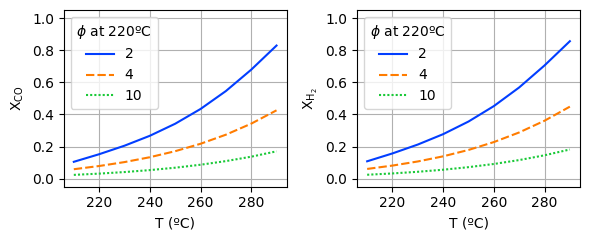

In [22]:
fig, ax = plt.subplots(1,2,figsize=(6,2.5))
sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20)],
            x = 'T (ºC)', y = r'$\mathrm{X_{CO}}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$\phi$ at 220ºC')
ax[0].set_ylim(-0.05, 1.05)
ax[0].grid('both')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['H2_CO'] == 2)],
            x = 'T (ºC)', y = r'$\mathrm{X_{H_2}}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[1]
            )
ax[1].legend(title = r'$\phi$ at 220ºC')
ax[1].set_ylim(-0.05, 1.05)
ax[1].grid('both')

plt.tight_layout()
fig_name = 'X_pilot_phi.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

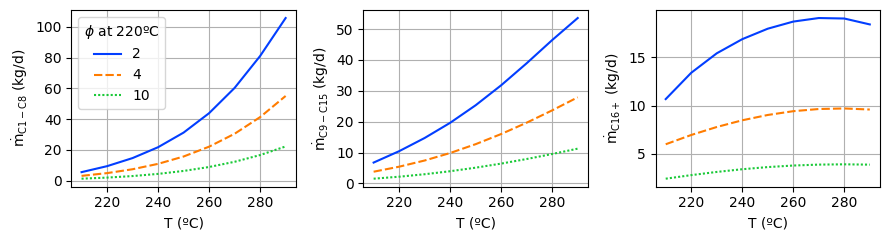

In [49]:
fig, ax = plt.subplots(1,3,figsize=(9,2.5))

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20)],
            x = 'T (ºC)', y = r'$\mathrm{\dot{m}_{C1-C8}}$ (kg/d)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$\phi$ at 220ºC')
ax[0].grid('both')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20)],
            x = 'T (ºC)', y = r'$\mathrm{\dot{m}_{C9-C15}}$ (kg/d)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[1]
            )
ax[1].legend().remove()
ax[1].grid('both')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20)],
            x = 'T (ºC)', y = r'$\mathrm{\dot{m}_{C16+}}$ (kg/d)', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[2]
            )
ax[2].legend().remove()
ax[2].grid('both')
plt.tight_layout()
fig_name = 'm_out_pilot.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

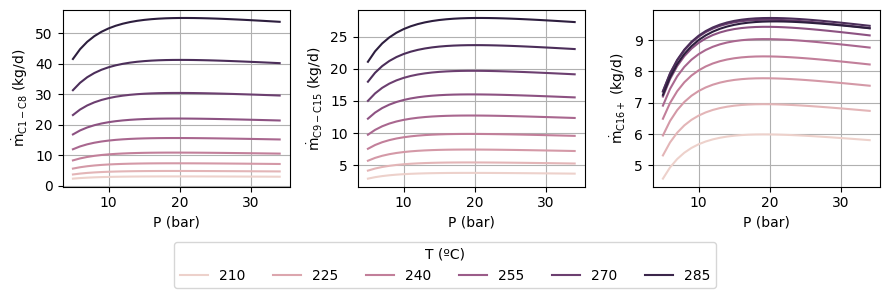

In [47]:
fig, ax = plt.subplots(1,3,figsize=(9,2.5))

sns.lineplot(data = parametric_data.loc[(parametric_data['phi_220C'] == 4)],
            x = 'P (bar)', y = r'$\mathrm{\dot{m}_{C1-C8}}$ (kg/d)', 
             hue = 'T (ºC)', ax = ax[0]
            )
ax[0].legend().remove()
ax[0].grid('both')

sns.lineplot(data = parametric_data.loc[(parametric_data['phi_220C'] == 4)],
            x = 'P (bar)', y = r'$\mathrm{\dot{m}_{C9-C15}}$ (kg/d)', 
             hue = 'T (ºC)', ax = ax[1]
            )
ax[1].legend().remove()
ax[1].grid('both')

sns.lineplot(data = parametric_data.loc[(parametric_data['phi_220C'] == 4)],
            x = 'P (bar)', y = r'$\mathrm{\dot{m}_{C16+}}$ (kg/d)', 
             hue = 'T (ºC)', ax = ax[2]
            )
ax[2].legend().remove()
ax[2].grid('both')

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.2), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True,
           title = 'T (ºC)',
          )

plt.tight_layout()
fig_name = 'm_out_pilot_P.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

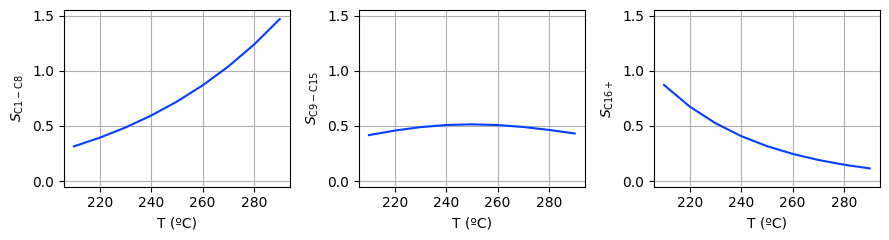

In [41]:
fig, ax = plt.subplots(1,3,figsize=(9,2.5))

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C1_C8_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[0], palette = 'bright',
            )
# ax[0].legend(title = r'$\phi$ at 220ºC')
ax[0].legend().remove()
ax[0].set_ylabel(r'$S_\mathrm{C1 - C8}$')
ax[0].set_ylim(-0.05, 1.55)
ax[0].grid('both')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C9_C15_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[1], palette = 'bright',
            )
ax[1].legend().remove()
ax[1].set_ylabel(r'$S_\mathrm{C9 - C15}$')
ax[1].set_ylim(-0.05, 1.55)
ax[1].grid('both')

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20) & (parametric_data['phi_220C'] == 4)],
            x = 'T (ºC)', y = 'C16p_sel', 
             hue = 'phi_220C', style = 'phi_220C', ax = ax[2], palette = 'bright',
            )
ax[2].legend().remove()
ax[2].set_ylabel(r'$S_\mathrm{C16+}$')
ax[2].set_ylim(-0.05, 1.55)
ax[2].grid('both')

plt.tight_layout()
fig_name = 'sel_pilot.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [54]:
parametric_data.loc[(parametric_data['P (bar)'] == 20) 
    & (parametric_data['T (ºC)'] == 220)]

,F_CO_in,F_H2_in,P_Pa,T_K,phi_220C,phi,eff,Reactor Energy Flow (kW),CO in mass flow (kg/d),H2 in mass flow (kg/d),...,$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,"$\mathrm{v_{CO,in}}$ (L/min)","$\mathrm{v_{H_2,in}}$ (L/min)",$\mathrm{\dot{m}_{C1-C8}}$ (kg/d),$\mathrm{\dot{m}_{C9-C15}}$ (kg/d),$\mathrm{\dot{m}_{C16+}}$ (kg/d),$\mathrm{\dot{m}_{H_2O}}$ (kg/d),C1_C8_sel,C16p_sel
408,0.178681,0.357361,2000000.0,493.15,2,2.010648,0.479832,-4.287150,432.420316,62.242367,...,0.152330,0.157332,243.333333,486.666667,9.383430,10.440691,13.404120,42.053608,0.393521,0.676152
409,0.178681,0.357361,2000000.0,493.15,4,4.021296,0.248516,-2.218897,432.420316,62.242367,...,0.078884,0.081610,243.333333,486.666667,4.864628,5.412746,6.949093,21.826363,0.393520,0.676155
410,0.178681,0.357361,2000000.0,493.15,10,10.053239,0.099470,-0.888058,432.420316,62.242367,...,0.031560,0.032699,243.333333,486.666667,1.948228,2.167750,2.783070,8.749967,0.393516,0.676162


In [ ]:
fig, ax = plt.subplots(1,2,figsize=(6,2.5))
sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20)],
            x = 'T (ºC)', y = r'$\mathrm{X_{CO}}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax[0]
            )
ax[0].legend(title = r'$\phi$ at 220ºC')
ax[0].set_ylim(-0.05, 1.05)
ax[0].grid('both')

In [56]:
parametric_data

,F_CO_in,F_H2_in,P_Pa,T_K,phi_220C,phi,eff,Reactor Energy Flow (kW),CO in mass flow (kg/d),H2 in mass flow (kg/d),...,$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,"$\mathrm{v_{CO,in}}$ (L/min)","$\mathrm{v_{H_2,in}}$ (L/min)",$\mathrm{\dot{m}_{C1-C8}}$ (kg/d),$\mathrm{\dot{m}_{C9-C15}}$ (kg/d),$\mathrm{\dot{m}_{C16+}}$ (kg/d),$\mathrm{\dot{m}_{H_2O}}$ (kg/d),C1_C8_sel,C16p_sel
0,0.178681,0.357361,500000.0,483.15,2,1.400948,0.632112,-2.241797,432.420316,62.242367,...,0.079999,0.082563,243.333333,486.666667,4.189908,5.145454,8.134425,22.189976,0.315508,0.871356
1,0.178681,0.357361,500000.0,483.15,4,2.801896,0.354281,-1.260574,432.420316,62.242367,...,0.044981,0.046448,243.333333,486.666667,2.356721,2.894196,4.575439,12.485810,0.315507,0.871360
2,0.178681,0.357361,500000.0,483.15,10,7.004741,0.142760,-0.509233,432.420316,62.242367,...,0.018166,0.018769,243.333333,486.666667,0.952155,1.169310,1.848588,5.046350,0.315503,0.871373
3,0.178681,0.357361,500000.0,493.15,2,2.010648,0.479832,-3.250405,432.420316,62.242367,...,0.115767,0.119875,243.333333,486.666667,7.143467,7.948347,10.204374,32.070362,0.393520,0.676153
4,0.178681,0.357361,500000.0,493.15,4,4.021296,0.248516,-1.693186,432.420316,62.242367,...,0.060280,0.062474,243.333333,486.666667,3.721846,4.141205,5.316650,16.719123,0.393519,0.676156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,0.178681,0.357361,3400000.0,553.15,4,26.612671,0.037576,-9.629413,432.420316,62.242367,...,0.335442,0.350584,243.333333,486.666667,40.200095,23.057529,9.450618,89.356102,1.236616,0.149399
806,0.178681,0.357361,3400000.0,553.15,10,66.531677,0.015030,-3.841813,432.420316,62.242367,...,0.133059,0.140850,243.333333,486.666667,16.084448,9.225550,3.781326,36.073464,1.236611,0.149400
807,0.178681,0.357361,3400000.0,563.15,2,17.522296,0.057070,-24.145237,432.420316,62.242367,...,0.846739,0.861288,243.333333,486.666667,106.857767,54.190083,18.633082,214.814543,1.467360,0.115699
808,0.178681,0.357361,3400000.0,563.15,4,35.044593,0.028535,-12.056114,432.420316,62.242367,...,0.418754,0.436790,243.333333,486.666667,53.748117,27.256940,9.372242,110.036256,1.467358,0.115699


In [82]:
Ri = ( 45.1 / 2 ) / 1000 # m
Re = ( ( 45.1 + 3.2 ) / 2 ) / 1000 # m

In [83]:
V = 45 / 1000 # m³

In [84]:
L = V / ( np.pi * Ri ** 2 )

In [85]:
L

28.168877986382718

In [86]:
A = 2 * np.pi * Re * L # m²

In [87]:
A

4.274315268853152

In [88]:
delta_T = 20 #K

In [101]:
parametric_data[r'$U_\mathrm{req}~\mathrm{(W~m^{-2}~K^{-1})}$'] = - parametric_data['Reactor Energy Flow (kW)'] * 1000 / ( A * delta_T )

In [102]:
$U_\mathrm{req}~\mathrm{(W~m^{-2}~K^{-1})}$

SyntaxError: invalid syntax (2938408481.py, line 1)

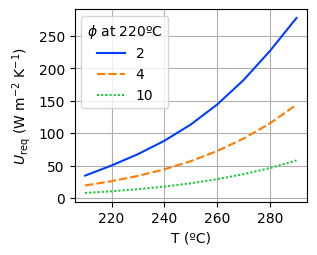

In [104]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.lineplot(data = parametric_data.loc[(parametric_data['P (bar)'] == 20)],
            x = 'T (ºC)', y = r'$U_\mathrm{req}~\mathrm{(W~m^{-2}~K^{-1})}$', 
             hue = 'phi_220C', style = 'phi_220C', palette = 'bright', ax = ax
            )
ax.grid('both')
ax.legend(title = r'$\phi$ at 220ºC')

fig_name = 'U_req.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()